# Real-data inversion comparison figures (Deepert vs paper-style interpretation)

This notebook creates two manuscript-ready figures from the **calibrated soft-constrained AD inversion** result:

1. Spatial evolution figure: temperature-corrected `Delta rho/rho0` and inverted `Delta theta` at four representative times.
2. Sensor-validation figure: time series, scatter, and depth-wise metrics comparing ERT-derived and sensor-derived `Delta theta`.


In [13]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.collections import PolyCollection
from matplotlib.colors import LogNorm, Normalize, TwoSlopeNorm
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')


def _pick_available_font(candidates: list[str]) -> str:
    for name in candidates:
        try:
            fm.findfont(name, fallback_to_default=False)
            return name
        except Exception:
            continue
    return 'DejaVu Sans'


preferred_font = _pick_available_font(['Arial', 'Liberation Sans', 'Nimbus Sans', 'DejaVu Sans'])
plt.rcParams.update({
    'font.family': preferred_font,
    'font.sans-serif': [preferred_font],
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 120,
})

np.set_printoptions(precision=4, suppress=True)
print('Using font:', preferred_font)


Using font: DejaVu Sans


In [14]:
# Resolve paths from repo root or from examples/8_real_data.
here = Path.cwd().resolve()
candidates = [here, *here.parents]
project_root = next((p for p in candidates if (p / 'deepert').exists() and (p / 'result').exists()), None)
if project_root is None:
    raise FileNotFoundError('Cannot locate project root containing deepert/ and result/.')

result_case = '7_ad_delta_theta_sensor_calibrated'
result_dir = project_root / 'result' / '8_real_data' / result_case
baseline_dir = project_root / 'result' / '8_real_data' / '2_timelapse_inversion_real_deepert'
if not result_dir.exists():
    raise FileNotFoundError(f'Missing result directory: {result_dir}')
if not baseline_dir.exists():
    raise FileNotFoundError(f'Missing baseline directory: {baseline_dir}')

save_figures = True
figure_dpi = 600

# Figure controls.
xlim = (0.0, 250.0)
ylim = (-90.0, 0.0)
rho0_clim = (70.0, 2500.0)
theta0_clim = (0.10, 0.30)
delta_rho_clim = (-0.30, 0.30)
delta_theta_clim = (-0.15, 0.15)

representative_times = [
    '2022-03-26 00:30',
    '2022-04-12 06:30',
    '2022-04-26 18:30',
    '2022-05-12 18:30',
]

print('project_root =', project_root)
print('result_case  =', result_case)
print('result_dir   =', result_dir)


project_root = /home/luffy/deepertv1
result_case  = 7_ad_delta_theta_sensor_calibrated
result_dir   = /home/luffy/deepertv1/result/8_real_data/7_ad_delta_theta_sensor_calibrated


## 1) Load inversion and sensor-comparison outputs


In [15]:
summary = json.loads((result_dir / 'timelapse_real_ad_delta_theta_summary.json').read_text())

rho_ref = np.load(result_dir / 'final_models_reference_temperature.npy')
rho0 = np.load(result_dir / 'rho0_baseline_resistivity.npy')
theta0 = np.load(result_dir / 'theta0_sensor_interpolated.npy')
delta_theta = np.load(result_dir / 'final_delta_theta_models.npy')
coverage_mask = np.load(result_dir / 'coverage_mask.npy').astype(bool)
measurement_times_days = np.load(result_dir / 'measurement_times_days.npy')

with np.load(result_dir / 'timelapse_inversion_mesh.npz') as mesh_data:
    nodes = np.asarray(mesh_data['nodes'], dtype=float)
    cells = np.asarray(mesh_data['cells'], dtype=np.int32)
    elec_x = np.asarray(mesh_data['elec_x'], dtype=float)
    elec_z = np.asarray(mesh_data['elec_z'], dtype=float)

delta_rho_rel = (rho_ref - rho0[:, None]) / rho0[:, None]

used_lines = (result_dir / 'used_data_files.txt').read_text().splitlines()
time_labels = [line.split('	')[0] for line in used_lines]
time_index = pd.DatetimeIndex(pd.to_datetime(time_labels))

def pick_indices_by_nearest(target_labels: list[str]) -> list[int]:
    out = []
    for label in target_labels:
        t = pd.Timestamp(label)
        idx = int(np.argmin(np.abs((time_index - t).total_seconds())))
        out.append(idx)
    return out

selected_indices = pick_indices_by_nearest(representative_times)
selected_labels = [time_labels[i] for i in selected_indices]

sensor_cmp = pd.read_csv(result_dir / 'ad_delta_theta_sensor_comparison.csv')
sensor_metrics = json.loads((result_dir / 'ad_delta_theta_sensor_metrics.json').read_text())

depth_metrics_file = result_dir / 'ad_delta_theta_sensor_metrics_by_depth.csv'
if depth_metrics_file.exists():
    depth_metrics = pd.read_csv(depth_metrics_file)
else:
    pred_col = 'delta_theta_ert' if 'delta_theta_ert' in sensor_cmp.columns else 'delta_theta_ert_estimate'
    rows = []
    for depth, sub in sensor_cmp.groupby('depth_m', sort=True):
        sub = sub.replace([np.inf, -np.inf], np.nan).dropna(subset=['delta_theta_sensor', pred_col])
        if sub.empty:
            continue
        residual = sub[pred_col].to_numpy(dtype=float) - sub['delta_theta_sensor'].to_numpy(dtype=float)
        corr = np.nan
        if len(sub) > 2 and np.std(sub['delta_theta_sensor']) > 0 and np.std(sub[pred_col]) > 0:
            corr = float(np.corrcoef(sub['delta_theta_sensor'], sub[pred_col])[0, 1])
        rows.append({
            'depth_m': float(depth),
            'n_points': int(len(sub)),
            'rmse_delta_theta': float(np.sqrt(np.mean(residual**2))),
            'mae_delta_theta': float(np.mean(np.abs(residual))),
            'bias_delta_theta': float(np.mean(residual)),
            'correlation': corr,
        })
    depth_metrics = pd.DataFrame(rows)

print('Selected panels:')
for idx, label in zip(selected_indices, selected_labels, strict=True):
    print(f'  index={idx:2d}   {label}')

print()
print('Summary final_chi2 =', summary.get('final_chi2'))
print('Sensor metrics:', sensor_metrics)


Selected panels:
  index= 0   2022-03-26 00:30
  index=12   2022-04-12 06:30
  index=23   2022-04-26 18:30
  index=35   2022-05-12 18:30

Summary final_chi2 = 9.20366879976536
Sensor metrics: {'case': '7_ad_delta_theta_sensor_calibrated', 'n_points': 702, 'rmse_delta_theta': 0.05927985016399458, 'mae_delta_theta': 0.046954532550285595, 'bias_delta_theta': -0.046408453501545384, 'correlation': 0.9539202854522618, 'ert_final_mean': 0.03130108432074283, 'sensor_final_mean': 0.12668947368421052}


## 2) Helper functions


In [16]:
def plot_cell_model(ax, values, *, cmap, norm, mask=None, edge=False, clim=None):
    values = np.asarray(values, dtype=float).ravel()
    visible = np.isfinite(values)
    if mask is not None:
        visible &= ~np.asarray(mask, dtype=bool).ravel()
    pc = PolyCollection(
        nodes[cells][visible],
        array=values[visible],
        cmap=cmap,
        norm=norm,
        edgecolors=(1, 1, 1, 0.16) if edge else 'none',
        linewidths=0.12 if edge else 0.0,
    )
    if clim is not None:
        pc.set_clim(float(clim[0]), float(clim[1]))
    ax.add_collection(pc)
    return pc


def plot_cell_model_smooth(
    ax,
    values,
    *,
    cmap,
    norm,
    mask=None,
    edge=False,
    clim=None,
    nx=700,
    nz=260,
    sigma=1.3,
):
    """Interpolate cell-centered values to a regular grid for display only."""
    from scipy.interpolate import griddata
    from scipy.ndimage import gaussian_filter

    values = np.asarray(values, dtype=float).ravel()
    centers = nodes[cells].mean(axis=1)

    visible = np.isfinite(values)
    if isinstance(norm, LogNorm):
        visible &= values > 0.0
    if mask is not None:
        visible &= ~np.asarray(mask, dtype=bool).ravel()
    if not np.any(visible):
        return plot_cell_model(ax, values, cmap=cmap, norm=norm, mask=mask, edge=edge, clim=clim)

    x_grid = np.linspace(xlim[0], xlim[1], int(nx))
    z_grid = np.linspace(ylim[0], ylim[1], int(nz))
    X, Z = np.meshgrid(x_grid, z_grid)

    V = griddata(centers[visible], values[visible], (X, Z), method='linear')

    # Keep the same visible support as the cell plot, and hide cells above topography.
    nearest_visible = griddata(centers, visible.astype(float), (X, Z), method='nearest')
    V[nearest_visible < 0.5] = np.nan
    top_z = np.interp(x_grid, elec_x, elec_z, left=np.nan, right=np.nan)
    V[Z > top_z[None, :]] = np.nan

    finite = np.isfinite(V)
    V0 = np.where(finite, V, 0.0)
    W = gaussian_filter(finite.astype(float), sigma=float(sigma))
    Vs = gaussian_filter(V0, sigma=float(sigma)) / np.maximum(W, 1.0e-12)
    Vs[W < 0.25] = np.nan

    im = ax.imshow(
        Vs,
        extent=(xlim[0], xlim[1], ylim[0], ylim[1]),
        origin='lower',
        cmap=cmap,
        norm=norm,
        interpolation='bilinear',
        aspect='auto',
    )
    if clim is not None:
        im.set_clim(float(clim[0]), float(clim[1]))
    return im


def format_section_axis(ax, *, show_xlabel=False, show_ylabel=False):
    ax.plot(elec_x, elec_z, color='black', lw=1.0, zorder=5)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(False)

    if show_xlabel:
        ax.set_xlabel('X (m)')
    else:
        ax.tick_params(axis='x', labelbottom=False)

    if show_ylabel:
        ax.set_ylabel('Z (m)')
    else:
        ax.tick_params(axis='y', labelleft=False)


def add_group_colorbar(fig, axes_group, mappable, label, *, pad=0.008, width=0.012):
    axes_flat = np.ravel(np.asarray(axes_group, dtype=object)).tolist()
    y0 = min(ax.get_position().y0 for ax in axes_flat)
    y1 = max(ax.get_position().y1 for ax in axes_flat)
    x1 = max(ax.get_position().x1 for ax in axes_flat)
    cax = fig.add_axes([x1 + pad, y0, width, y1 - y0])
    cbar = fig.colorbar(mappable, cax=cax)
    cbar.set_label(label)
    cbar.ax.tick_params(labelsize=11)
    return cbar


def add_row_colorbar(fig, row_axes, mappable, label):
    return add_group_colorbar(fig, row_axes, mappable, label)


def savefig(fig, filename):
    if save_figures:
        out = result_dir / filename
        fig.savefig(out, dpi=figure_dpi, bbox_inches='tight')
        print('saved:', out)


## 3) Figure 1: Spatial evolution (`Delta rho/rho0` and `Delta theta`)


saved: /home/luffy/deepertv1/result/8_real_data/7_ad_delta_theta_sensor_calibrated/paper_compare_fig1_spatial_evolution.png


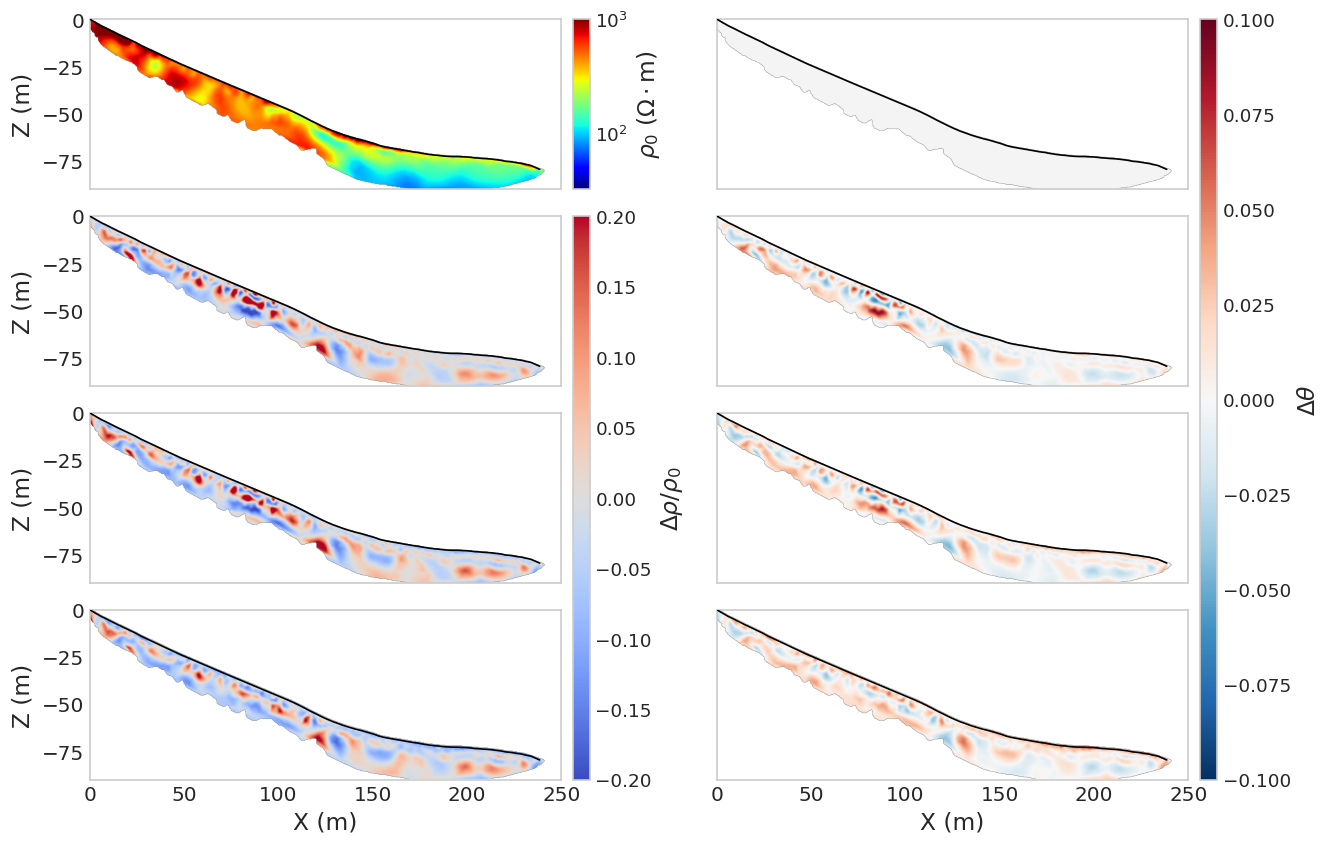

In [17]:
fig, axes = plt.subplots(4, 2, figsize=(11.8, 7.2), sharex=True, sharey=True)

rho0_norm = LogNorm(vmin=32, vmax=1000)
rho_delta_norm = TwoSlopeNorm(vmin=-0.2, vcenter=0.0, vmax=0.2)
theta_delta_norm = TwoSlopeNorm(vmin=-0.1, vcenter=0.0, vmax=0.1)
zero_delta_theta = np.zeros_like(delta_theta[:, 0])

# Row 1: baseline resistivity and zero water-content change by definition.
rho0_pc = plot_cell_model_smooth(axes[0, 0], rho0, cmap='jet', norm=rho0_norm, mask=coverage_mask)
theta_delta_pc = plot_cell_model_smooth(axes[0, 1], zero_delta_theta, cmap='BrBG', norm=theta_delta_norm, mask=coverage_mask)
format_section_axis(axes[0, 0], show_xlabel=False, show_ylabel=True)
format_section_axis(axes[0, 1], show_xlabel=False, show_ylabel=False)

# Rows 2-4: changes relative to the baseline survey.
rho_delta_pc = None
for row, (idx, label) in enumerate(zip(selected_indices[1:], selected_labels[1:], strict=True), start=1):
    rho_delta_pc = plot_cell_model_smooth(axes[row, 0], delta_rho_rel[:, idx], cmap='coolwarm', norm=rho_delta_norm, mask=coverage_mask)
    theta_delta_pc = plot_cell_model_smooth(axes[row, 1], delta_theta[:, idx], cmap='RdBu_r', norm=theta_delta_norm, mask=coverage_mask)

    format_section_axis(axes[row, 0], show_xlabel=(row == 3), show_ylabel=True)
    format_section_axis(axes[row, 1], show_xlabel=(row == 3), show_ylabel=False)

fig.subplots_adjust(left=0.08, right=0.88, top=0.95, bottom=0.07, wspace=0.24, hspace=0.16)

add_group_colorbar(fig, axes[0, 0], rho0_pc, '$\\rho_0$ ($\\Omega\\cdot$m)')
add_group_colorbar(fig, axes[1:, 0], rho_delta_pc, '$\\Delta\\rho/\\rho_0$')
add_group_colorbar(fig, axes[:, 1], theta_delta_pc, '$\\Delta\\theta$')

savefig(fig, 'paper_compare_fig1_spatial_evolution.png')
plt.show()


## 4) Figure 2: Sensor-based quantitative validation


saved: /home/luffy/deepertv1/result/8_real_data/7_ad_delta_theta_sensor_calibrated/paper_compare_fig2_sensor_validation.png


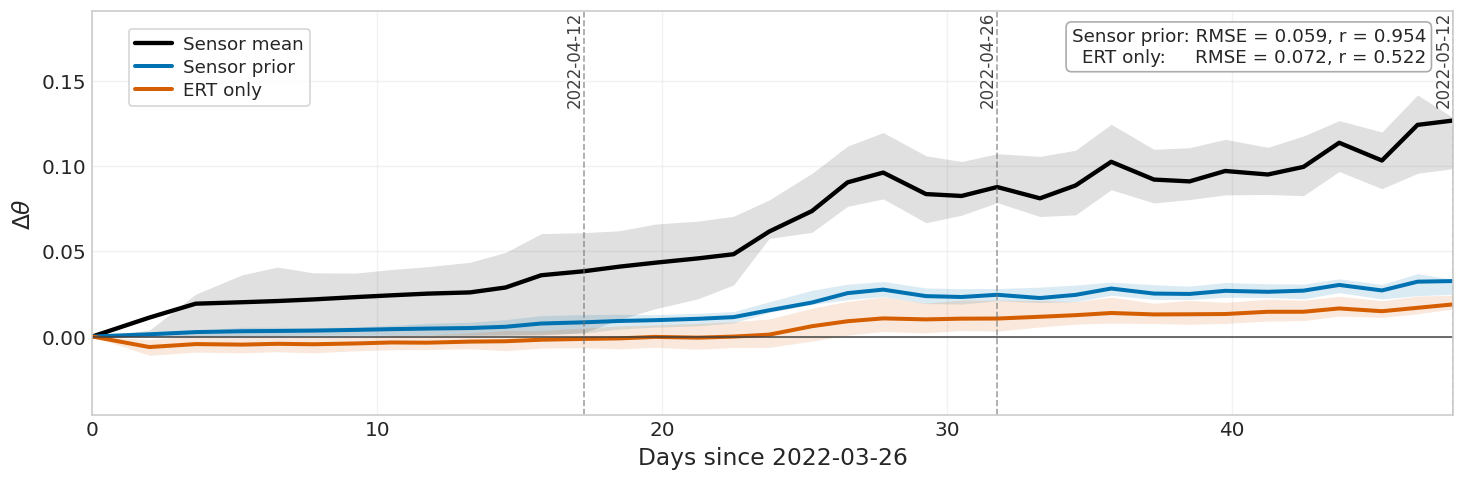

In [19]:
import scipy.sparse as sp

pred_col = 'delta_theta_ert' if 'delta_theta_ert' in sensor_cmp.columns else 'delta_theta_ert_estimate'
valid = sensor_cmp.replace([np.inf, -np.inf], np.nan).dropna(
    subset=['delta_theta_sensor', pred_col, 'day_since_baseline']
)

no_sensor_result_case = '6_relative_archie_delta_theta_inversion_real_deepert'
no_sensor_result_dir = project_root / 'result' / '8_real_data' / no_sensor_result_case
if not no_sensor_result_dir.exists():
    raise FileNotFoundError(f'Missing no-sensor result directory: {no_sensor_result_dir}')

sensor_operator = sp.load_npz(result_dir / 'sensor_constraint_operator.npz')
no_sensor_theta = np.load(no_sensor_result_dir / 'final_water_content_models.npy')
no_sensor_measurement_times_days = np.load(no_sensor_result_dir / 'measurement_times_days.npy')
if no_sensor_theta.shape[1] != len(measurement_times_days):
    raise ValueError('No-sensor result has a different number of timesteps.')
if not np.allclose(no_sensor_measurement_times_days, measurement_times_days):
    raise ValueError('No-sensor result uses a different measurement time axis.')

no_sensor_theta_at_sensors = np.asarray(sensor_operator @ no_sensor_theta, dtype=float)
no_sensor_delta_at_sensors = no_sensor_theta_at_sensors - no_sensor_theta_at_sensors[:, [0]]
no_sensor_cmp = valid.copy()
no_sensor_cmp['delta_theta_ert_no_sensor'] = no_sensor_delta_at_sensors[
    no_sensor_cmp['row_index'].to_numpy(dtype=int),
    no_sensor_cmp['time_index'].to_numpy(dtype=int),
]

def summarize_delta_timeseries(table, value_col):
    grouped = table.groupby('day_since_baseline')[value_col]
    return grouped.agg(
        mean='mean',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
    ).reset_index()

def sensor_fit_metrics(table, value_col):
    residual = table[value_col].to_numpy(dtype=float) - table['delta_theta_sensor'].to_numpy(dtype=float)
    rmse = float(np.sqrt(np.mean(residual**2))) if residual.size else np.nan
    corr = np.nan
    if residual.size > 2 and np.std(table['delta_theta_sensor']) > 0 and np.std(table[value_col]) > 0:
        corr = float(np.corrcoef(table['delta_theta_sensor'], table[value_col])[0, 1])
    return rmse, corr

sensor_ts = summarize_delta_timeseries(valid, 'delta_theta_sensor')
ert_ts = summarize_delta_timeseries(valid, pred_col)
no_sensor_ert_ts = summarize_delta_timeseries(no_sensor_cmp, 'delta_theta_ert_no_sensor')
no_sensor_rmse, no_sensor_corr = sensor_fit_metrics(no_sensor_cmp, 'delta_theta_ert_no_sensor')

fig, ax = plt.subplots(1, 1, figsize=(12.6, 4.8))

sensor_color = 'black'
ert_color = '#0072B2'
no_sensor_color = '#D55E00'

ax.fill_between(
    sensor_ts['day_since_baseline'], sensor_ts['q25'], sensor_ts['q75'],
    color=sensor_color, alpha=0.12, lw=0.0, label='_nolegend_'
)
ax.plot(
    sensor_ts['day_since_baseline'], sensor_ts['mean'],
    color=sensor_color, lw=2.6, label='Sensor mean'
)

ax.fill_between(
    ert_ts['day_since_baseline'], ert_ts['q25'], ert_ts['q75'],
    color=ert_color, alpha=0.14, lw=0.0, label='_nolegend_'
)
ax.plot(
    ert_ts['day_since_baseline'], ert_ts['mean'],
    color=ert_color, lw=2.4, label='Sensor prior'
)

ax.fill_between(
    no_sensor_ert_ts['day_since_baseline'], no_sensor_ert_ts['q25'], no_sensor_ert_ts['q75'],
    color=no_sensor_color, alpha=0.14, lw=0.0, label='_nolegend_'
)
ax.plot(
    no_sensor_ert_ts['day_since_baseline'], no_sensor_ert_ts['mean'],
    color=no_sensor_color, lw=2.4, label='ERT only'
)

band_values = pd.concat(
    [
        sensor_ts[['q25', 'q75']].stack(),
        ert_ts[['q25', 'q75']].stack(),
        no_sensor_ert_ts[['q25', 'q75']].stack(),
    ],
    ignore_index=True,
)
ymin = min(-0.035, float(band_values.min()))
ymax = max(0.18, float(band_values.max()))
y_pad = 0.05 * max(ymax - ymin, 1.0e-6)
ymin -= y_pad
ymax += y_pad

# Mark the representative dates used in the spatial-evolution figure.
for idx, label in zip(selected_indices[1:], selected_labels[1:], strict=True):
    day = float(measurement_times_days[idx])
    ax.axvline(day, color='0.45', lw=1.0, ls='--', alpha=0.65)
    ax.text(day, ymax, label.split()[0], rotation=90, va='top', ha='right', fontsize=10, color='0.25')

ax.axhline(0.0, color='0.25', lw=0.9)
ax.set_xlim(float(measurement_times_days.min()), float(measurement_times_days.max()))
ax.set_ylim(ymin, ymax)
ax.set_xlabel('Days since 2022-03-26')
ax.set_ylabel('$\\Delta\\theta$')
ax.grid(alpha=0.25)

legend = ax.legend(
    loc='upper left',
    bbox_to_anchor=(0.02, 0.98),
    ncol=1,
    frameon=True,
    borderpad=0.35,
    labelspacing=0.28,
    handlelength=2.0,
    handletextpad=0.6,
)

rmse = sensor_metrics.get('rmse_delta_theta', np.nan)
corr = sensor_metrics.get('correlation', np.nan)
metric_text = (
    f'Sensor prior: RMSE = {rmse:.3f}, r = {corr:.3f}\n'
    f'ERT only:     RMSE = {no_sensor_rmse:.3f}, r = {no_sensor_corr:.3f}'
)
ax.text(
    0.98,
    0.96,
    metric_text,
    transform=ax.transAxes,
    va='top',
    ha='right',
    fontsize=11,
    bbox=dict(boxstyle='round,pad=0.30', fc='white', ec='0.65', alpha=0.93),
    zorder=8,
    clip_on=False,
)
fig.subplots_adjust(left=0.08, right=0.98, top=0.88, bottom=0.18)
savefig(fig, 'paper_compare_fig2_sensor_validation.png')
plt.show()
